# SVM Benchmark — Stratified 5-Fold Cross-Validation

Evaluates all scikit-svm classifiers on UCI binary and multiclass datasets
using stratified 5-fold cross-validation.  Results are reported as
mean ± standard deviation across folds.

**Binary datasets**: German Credit, Australian Credit, Breast Cancer
(Wisconsin Diagnostic), Ionosphere.

**Multiclass datasets**: Heart Disease (5 classes), Wine (3 classes).
Binary-only classifiers are wrapped with `OneVsRestClassifier` for
multiclass tasks.

**Metrics**: Accuracy, F1 (weighted for multiclass), ROC-AUC, MCC,
Precision, Recall, Fit time.

In [1]:
import os
import signal
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    matthews_corrcoef, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from ucimlrepo import fetch_ucirepo

import scikit_svm as sv

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
N_FOLDS         = 5
TIMEOUT_SECONDS = 180
RESULTS_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()

In [2]:
class Pm1Wrapper(ClassifierMixin, BaseEstimator):
    """Adapts classifiers requiring ±1 labels to arbitrary binary labels.

    Uses :class:`~sklearn.preprocessing.LabelEncoder` for encoding and
    decoding, so any two-class label type is accepted.
    """

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        self._le = LabelEncoder()
        y_01 = self._le.fit_transform(y)               # integer 0 or 1
        self.classes_ = self._le.classes_
        y_pm1 = (2 * y_01 - 1).astype(float)           # 0 → -1,  1 → +1
        self.estimator.fit(X, y_pm1)
        return self

    def predict(self, X):
        y_pm1 = self.estimator.predict(X)
        y_01  = (y_pm1 > 0).astype(int)                # -1 → 0,  +1 → 1
        return self._le.inverse_transform(y_01)

    def decision_function(self, X):
        return self.estimator.decision_function(X)

In [3]:
class _TimeoutError(Exception):
    pass


def _timeout(seconds):
    def _handler(signum, frame):
        raise _TimeoutError(f"timed out after {seconds}s")

    def decorator(fn):
        def wrapper(*args, **kwargs):
            prev = signal.signal(signal.SIGALRM, _handler)
            signal.alarm(seconds)
            try:
                return fn(*args, **kwargs)
            finally:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, prev)
        return wrapper
    return decorator

In [4]:
def _prepare_features(X_df):
    X_df = X_df.copy()
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns
    num_cols = X_df.select_dtypes(exclude=["object", "category"]).columns
    X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
    if len(cat_cols):
        X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=False)
    return X_df.values.astype(float)


_BINARY_SPECS = [
    (144, "German Credit",     lambda y: (y - 1).astype(int)),
    (143, "Australian Credit", lambda y: y.astype(int)),
    ( 17, "Breast Cancer",     lambda y: LabelEncoder().fit_transform(y).astype(int)),
    ( 52, "Ionosphere",        lambda y: LabelEncoder().fit_transform(y).astype(int)),
]

_MULTICLASS_SPECS = [
    ( 45, "Heart Disease",     lambda y: y.astype(int)),
    (109, "Wine",              lambda y: LabelEncoder().fit_transform(y).astype(int)),
]


def load_datasets(specs):
    datasets = {}
    for ds_id, name, label_fn in specs:
        try:
            raw = fetch_ucirepo(id=ds_id)
            X = _prepare_features(raw.data.features)
            y = label_fn(raw.data.targets.values.ravel())
            n_cls = len(np.unique(y))
            print(f"  {name:<22} {X.shape[0]:>4} × {X.shape[1]:<3}  "
                  f"{n_cls} classes  {np.bincount(y).tolist()}")
            datasets[name] = (X, y)
        except Exception as exc:
            print(f"  {name:<22} FAILED — {exc}")
    return datasets

In [5]:
def get_binary_classifiers():
    clfs = []

    clfs.append(("LSVM",          Pm1Wrapper(sv.LSVM(verbose=False))))
    clfs.append(("SSVM",          Pm1Wrapper(sv.SSVM(verbose=False))))
    clfs.append(("NSSVM",         Pm1Wrapper(sv.NSSVM(verbose=False))))
    clfs.append(("PSVM",          sv.PSVMClassifier()))

    clfs.append(("LSVMK(rbf)",    Pm1Wrapper(sv.LSVMK(kernel="rbf", verbose=False))))
    clfs.append(("LSSVM(rbf)",    sv.LSSVMClassifier(kernel="rbf")))
    clfs.append(("N-PSVM",        sv.NPSVMClassifier()))
    clfs.append(("LapSVM",        sv.LapSVMClassifier()))

    if sv._HAS_LIBOCAS:
        clfs.append(("SVMOCAS",   sv.SVMOCASClassifier()))
    if sv._HAS_LIBCVM:
        clfs.append(("CVM",       Pm1Wrapper(sv.CVM())))
        clfs.append(("BVM",       Pm1Wrapper(sv.BVM())))
    if sv._HAS_LIBBSVM:
        clfs.append(("BSVM",      sv.BSVMClassifier()))
    if sv._HAS_LIBSVMLIGHT:
        clfs.append(("SVMLight",  sv.SVMLightClassifier()))
    if sv._HAS_LIBMYSVM:
        clfs.append(("MySVM",     sv.MySVMClassifier()))
    if sv._HAS_LIBLINEAR:
        clfs.append(("LibLinear", sv.LibLinearSVC()))

    clfs.append(("sklearn SVC",       SVC(kernel="rbf")))
    clfs.append(("sklearn LinearSVC", LinearSVC(max_iter=2000)))
    return clfs


def get_multiclass_classifiers():
    OvR = OneVsRestClassifier
    clfs = []

    # ±1-only → OvR( Pm1Wrapper( base ) )
    clfs.append(("LSVM (OvR)",        OvR(Pm1Wrapper(sv.LSVM(verbose=False)))))
    clfs.append(("SSVM (OvR)",        OvR(Pm1Wrapper(sv.SSVM(verbose=False)))))
    clfs.append(("NSSVM (OvR)",       OvR(Pm1Wrapper(sv.NSSVM(verbose=False)))))
    clfs.append(("LSVMK(rbf) (OvR)",  OvR(Pm1Wrapper(sv.LSVMK(kernel="rbf", verbose=False)))))

    # Binary with internal encoding → OvR( base )
    clfs.append(("PSVM (OvR)",        OvR(sv.PSVMClassifier())))
    clfs.append(("N-PSVM (OvR)",      OvR(sv.NPSVMClassifier())))
    clfs.append(("LapSVM (OvR)",      OvR(sv.LapSVMClassifier())))

    if sv._HAS_LIBOCAS:
        clfs.append(("SVMOCAS (OvR)", OvR(sv.SVMOCASClassifier())))
    if sv._HAS_LIBCVM:
        clfs.append(("CVM (OvR)",     OvR(Pm1Wrapper(sv.CVM()))))
        clfs.append(("BVM (OvR)",     OvR(Pm1Wrapper(sv.BVM()))))
    if sv._HAS_LIBSVMLIGHT:
        clfs.append(("SVMLight (OvR)",OvR(sv.SVMLightClassifier())))
    if sv._HAS_LIBMYSVM:
        clfs.append(("MySVM (OvR)",   OvR(sv.MySVMClassifier())))

    # Native multiclass
    clfs.append(("LSSVM(rbf)",        sv.LSSVMClassifier(kernel="rbf")))
    if sv._HAS_LIBBSVM:
        clfs.append(("BSVM",          sv.BSVMClassifier()))
    if sv._HAS_LIBLINEAR:
        clfs.append(("LibLinear",     sv.LibLinearSVC()))
    if sv._HAS_LIBOCAS:
        clfs.append(("MSVMOCAS",      sv.MSVMOCASClassifier()))

    clfs.append(("sklearn SVC",       SVC(kernel="rbf")))
    clfs.append(("sklearn LinearSVC", LinearSVC(max_iter=2000)))
    return clfs

In [6]:
def _get_scores_binary(clf, X_test):
    try:
        return clf.decision_function(X_test)
    except AttributeError:
        pass
    try:
        return clf.predict_proba(X_test)[:, 1]
    except AttributeError:
        return None


def _get_scores_multiclass(clf, X_test, n_classes):
    try:
        proba = clf.predict_proba(X_test)
        if proba.shape[1] == n_classes:
            return proba
    except (AttributeError, NotImplementedError):
        pass
    try:
        df = clf.decision_function(X_test)
        if df.ndim == 2 and df.shape[1] == n_classes:
            df = df - df.max(axis=1, keepdims=True)
            e  = np.exp(df)
            return e / e.sum(axis=1, keepdims=True)
    except (AttributeError, NotImplementedError):
        pass
    return None


def _fold_metrics(clf, X_tr, y_tr, X_te, y_te, multiclass=False):
    t0 = time.perf_counter()
    clf.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0
    y_pred = clf.predict(X_te)

    avg = "weighted" if multiclass else "binary"
    n_classes = len(np.unique(np.concatenate([y_tr, y_te])))

    auc = float("nan")
    if multiclass:
        scores = _get_scores_multiclass(clf, X_te, n_classes)
        if scores is not None:
            try:
                auc = roc_auc_score(y_te, scores, multi_class="ovr", average="weighted")
            except Exception:
                pass
    else:
        scores = _get_scores_binary(clf, X_te)
        if scores is not None:
            try:
                auc = roc_auc_score(y_te, scores)
                if auc < 0.5:
                    auc = 1.0 - auc
            except Exception:
                pass

    return {
        "accuracy":  accuracy_score(y_te, y_pred),
        "f1":        f1_score(y_te, y_pred, average=avg, zero_division=0),
        "auc":       auc,
        "mcc":       matthews_corrcoef(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, average=avg, zero_division=0),
        "recall":    recall_score(y_te, y_pred, average=avg, zero_division=0),
        "fit_time":  fit_time,
    }

In [7]:
_METRIC_DISPLAY = {
    "accuracy": "Accuracy", "f1": "F1", "auc": "AUC",
    "mcc": "MCC", "precision": "Precision", "recall": "Recall",
    "fit_time": "Fit Time (s)",
}


def evaluate_cv(clf_proto, X, y, cv, multiclass=False):
    @_timeout(TIMEOUT_SECONDS)
    def _run_all_folds():
        results = {k: [] for k in _METRIC_DISPLAY}
        for train_idx, test_idx in cv.split(X, y):
            clf = clone(clf_proto)
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)
            m = _fold_metrics(clf, X_tr, y_tr, X_te, y_te, multiclass=multiclass)
            for k, v in m.items():
                results[k].append(v)
        return results

    try:
        return _run_all_folds(), None
    except _TimeoutError as exc:
        return None, f"TIMEOUT ({exc})"
    except Exception as exc:
        return None, f"ERROR: {exc}"

In [8]:
def run_benchmark(datasets, classifiers, multiclass=False):
    records = []
    tag = "multiclass" if multiclass else "binary"
    cv  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for ds_name, (X, y) in datasets.items():
        n_cls = len(np.unique(y))
        sep   = "─" * 64
        print(sep)
        print(f"  [{tag}] {ds_name}  ({X.shape[0]} × {X.shape[1]}, "
              f"{n_cls} classes, {N_FOLDS}-fold CV)")
        print(sep)

        for clf_name, clf_proto in classifiers:
            print(f"  {clf_name:<28}", end="", flush=True)
            fold_data, err = evaluate_cv(clf_proto, X, y, cv, multiclass=multiclass)

            if err is not None:
                print(f"  {err}")
                records.append({"Dataset": ds_name, "Classifier": clf_name,
                                "Task": tag, "Status": err})
                continue

            row = {"Dataset": ds_name, "Classifier": clf_name,
                   "Task": tag, "n_samples": X.shape[0],
                   "n_features": X.shape[1], "n_classes": n_cls,
                   "n_folds": N_FOLDS, "Status": "OK"}

            for raw_key, col_name in _METRIC_DISPLAY.items():
                vals = np.array(fold_data[raw_key])
                row[col_name]          = round(float(np.nanmean(vals)), 4)
                row[col_name + " Std"] = round(float(np.nanstd(vals[~np.isnan(vals)])), 4) \
                                         if (~np.isnan(vals)).sum() > 1 else float("nan")

            acc_s = row.get("Accuracy", float("nan"))
            auc_s = row.get("AUC",      float("nan"))
            f1_s  = row.get("F1",       float("nan"))
            t_s   = row.get("Fit Time (s)", float("nan"))
            std_s = row.get("Accuracy Std", float("nan"))
            print(f"  Acc={acc_s:.4f}±{std_s:.4f}  "
                  f"AUC={auc_s:.4f}  F1={f1_s:.4f}  time={t_s:.3f}s/fold")
            records.append(row)

        print()

    return pd.DataFrame(records)

In [9]:
def display_summary(df, task_label):
    ok = df[df["Status"] == "OK"]
    mean_cols = [v for v in _METRIC_DISPLAY.values()]
    std_cols  = [c + " Std" for c in mean_cols]

    print(f"\n{'='*80}")
    print(f"  {task_label.upper()} — MEAN ± STD ACROSS FOLDS")
    print(f"{'='*80}")

    for ds_name, grp in df.groupby("Dataset"):
        print(f"\n── {ds_name} ──")
        ok_grp = grp[grp["Status"] == "OK"]
        if ok_grp.empty:
            print("  (no successful results)")
            continue
        display_rows = []
        for _, row in ok_grp.iterrows():
            r = {"Classifier": row["Classifier"]}
            for col in mean_cols:
                std_col = col + " Std"
                if col in row and std_col in row and not np.isnan(row[std_col]):
                    r[col] = f"{row[col]:.4f} ± {row[std_col]:.4f}"
                elif col in row:
                    r[col] = f"{row[col]:.4f}"
            display_rows.append(r)
        disp = pd.DataFrame(display_rows).set_index("Classifier")
        print(disp.to_string())

    if ok.empty:
        return

    print(f"\n{'='*80}")
    print(f"  {task_label.upper()} — RANKING BY AVERAGE ACCURACY")
    print(f"{'='*80}")
    rank = (
        ok.groupby("Classifier")["Accuracy"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Mean Acc", "std": "Std", "count": "Datasets"})
        .sort_values("Mean Acc", ascending=False)
    )
    print(rank.to_string())

In [10]:
def plot_results(df, title, save_path=None):
    ok = df[df["Status"] == "OK"].copy()
    if ok.empty:
        print("No successful results to plot.")
        return

    n_clf = len(ok["Classifier"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, n_clf * 0.4 + 2)))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    acc_pivot = ok.pivot_table(index="Classifier", columns="Dataset", values="Accuracy")
    sns.heatmap(acc_pivot, ax=axes[0], annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0, linewidths=0.5,
                cbar_kws={"label": "Mean Accuracy"})
    axes[0].set_title(f"Mean Accuracy ({N_FOLDS} folds)")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].tick_params(axis="y", rotation=0)

    auc_pivot = ok.pivot_table(index="Classifier", columns="Dataset", values="AUC")
    auc_pivot_clean = auc_pivot.dropna(how="all")
    if not auc_pivot_clean.empty:
        sns.heatmap(auc_pivot_clean, ax=axes[1], annot=True, fmt=".3f",
                    cmap="RdYlGn", vmin=0.5, vmax=1.0, linewidths=0.5,
                    cbar_kws={"label": "Mean AUC"})
        axes[1].set_title(f"Mean AUC ({N_FOLDS} folds)")
        axes[1].tick_params(axis="x", rotation=35)
        axes[1].tick_params(axis="y", rotation=0)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved → {save_path}")
    plt.show()

  LOADING BINARY DATASETS


  German Credit          1000 × 61   2 classes  [700, 300]


  Australian Credit       690 × 14   2 classes  [383, 307]


  Breast Cancer           569 × 30   2 classes  [357, 212]


  Ionosphere              351 × 34   2 classes  [126, 225]

  LOADING MULTICLASS DATASETS


...

  Acc=0.9719±0.0004  AUC=0.9990  F1=0.9720  time=0.005s/fold
  sklearn SVC                 

  Acc=0.9833±0.0222  AUC=0.9997  F1=0.9833  time=0.002s/fold
  sklearn LinearSVC           

  Acc=0.9776±0.0112  AUC=0.9995  F1=0.9777  time=0.001s/fold


  BINARY BENCHMARK — MEAN ± STD ACROSS FOLDS

── Australian Credit ──
                          Accuracy               F1              AUC              MCC        Precision           Recall     Fit Time (s)
Classifier                                                                                                                              
LSVM               0.8652 ± 0.0313  0.8498 ± 0.0344  0.9284 ± 0.0135  0.7286 ± 0.0637  0.8443 ± 0.0414  0.8568 ± 0.0437  0.0024 ± 0.0003
SSVM               0.8667 ± 0.0319  0.8586 ± 0.0331  0.9293 ± 0.0190  0.7379 ± 0.0645  0.8141 ± 0.0354  0.9090 ± 0.0416  0.3344 ± 0.0607
NSSVM              0.5870 ± 0.0205  0.1660 ± 0.0686  0.8649 ± 0.0290  0.1757 ± 0.0722  0.8669 ± 0.1675  0.0943 ± 0.0416  1.2370 ± 0.1778
PSVM               0.8609 ± 0.0325  0.8550 ± 0.0332  0.9281 ± 0.0168  0.7307 ± 0.0660  0.7981 ± 0.0362  0.9219 ± 0.0440  0.3305 ± 0.1732
LSVMK(rbf)         0.8246 ± 0.0148  0.7733 ± 


Results saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_cv.csv


  Figure saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_cv_binary.png


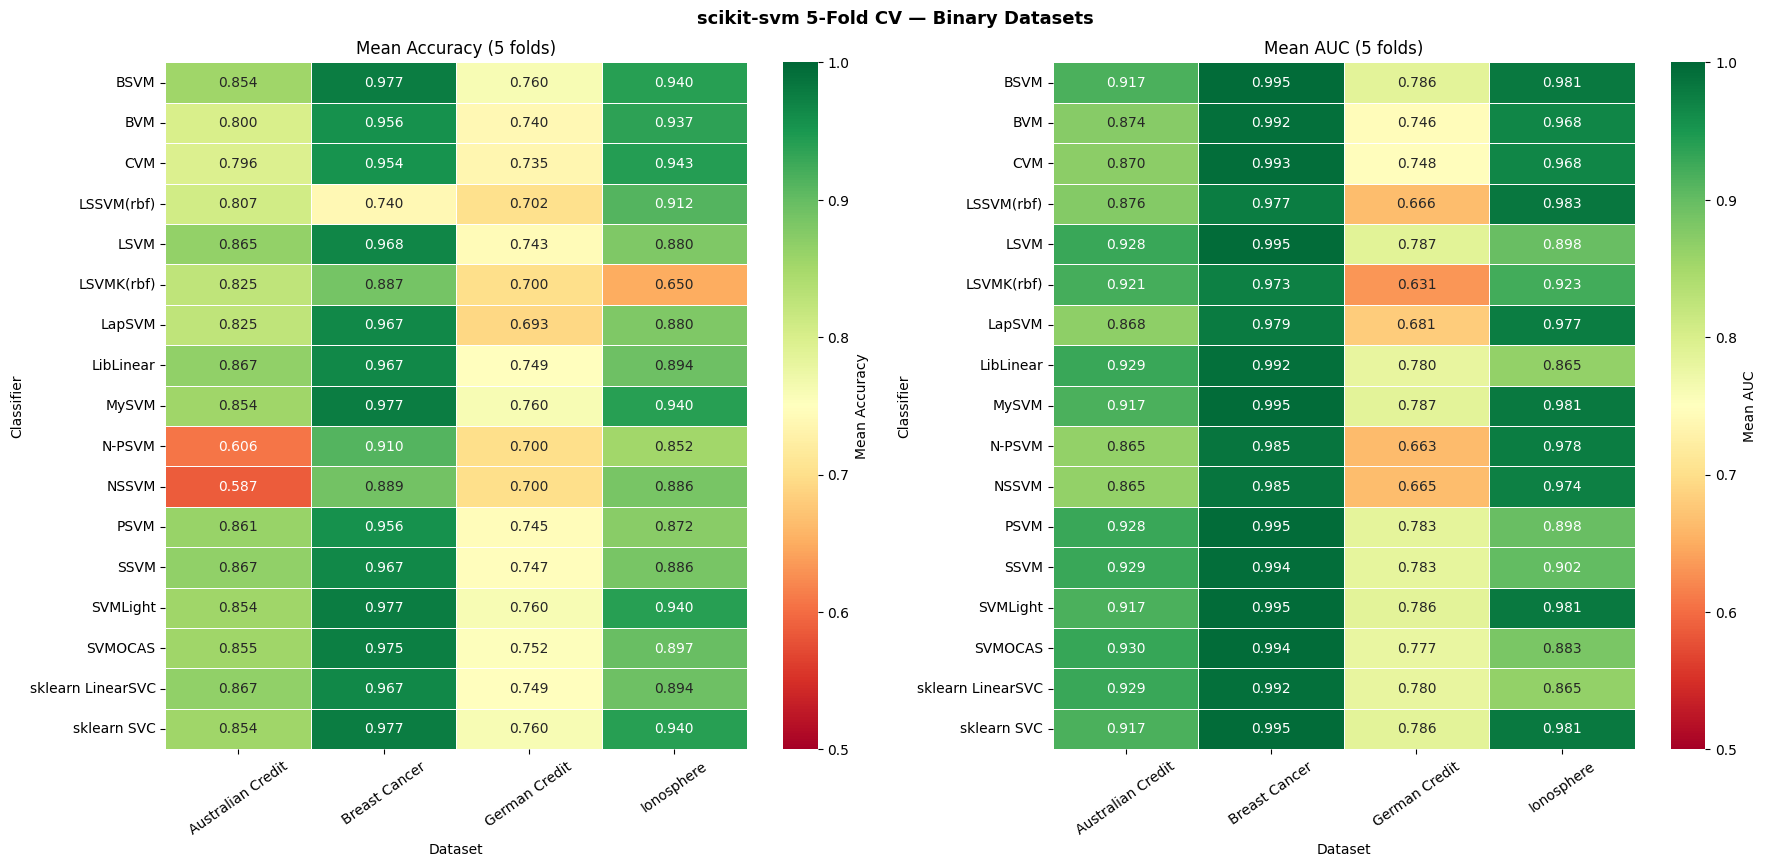

  Figure saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_cv_multiclass.png


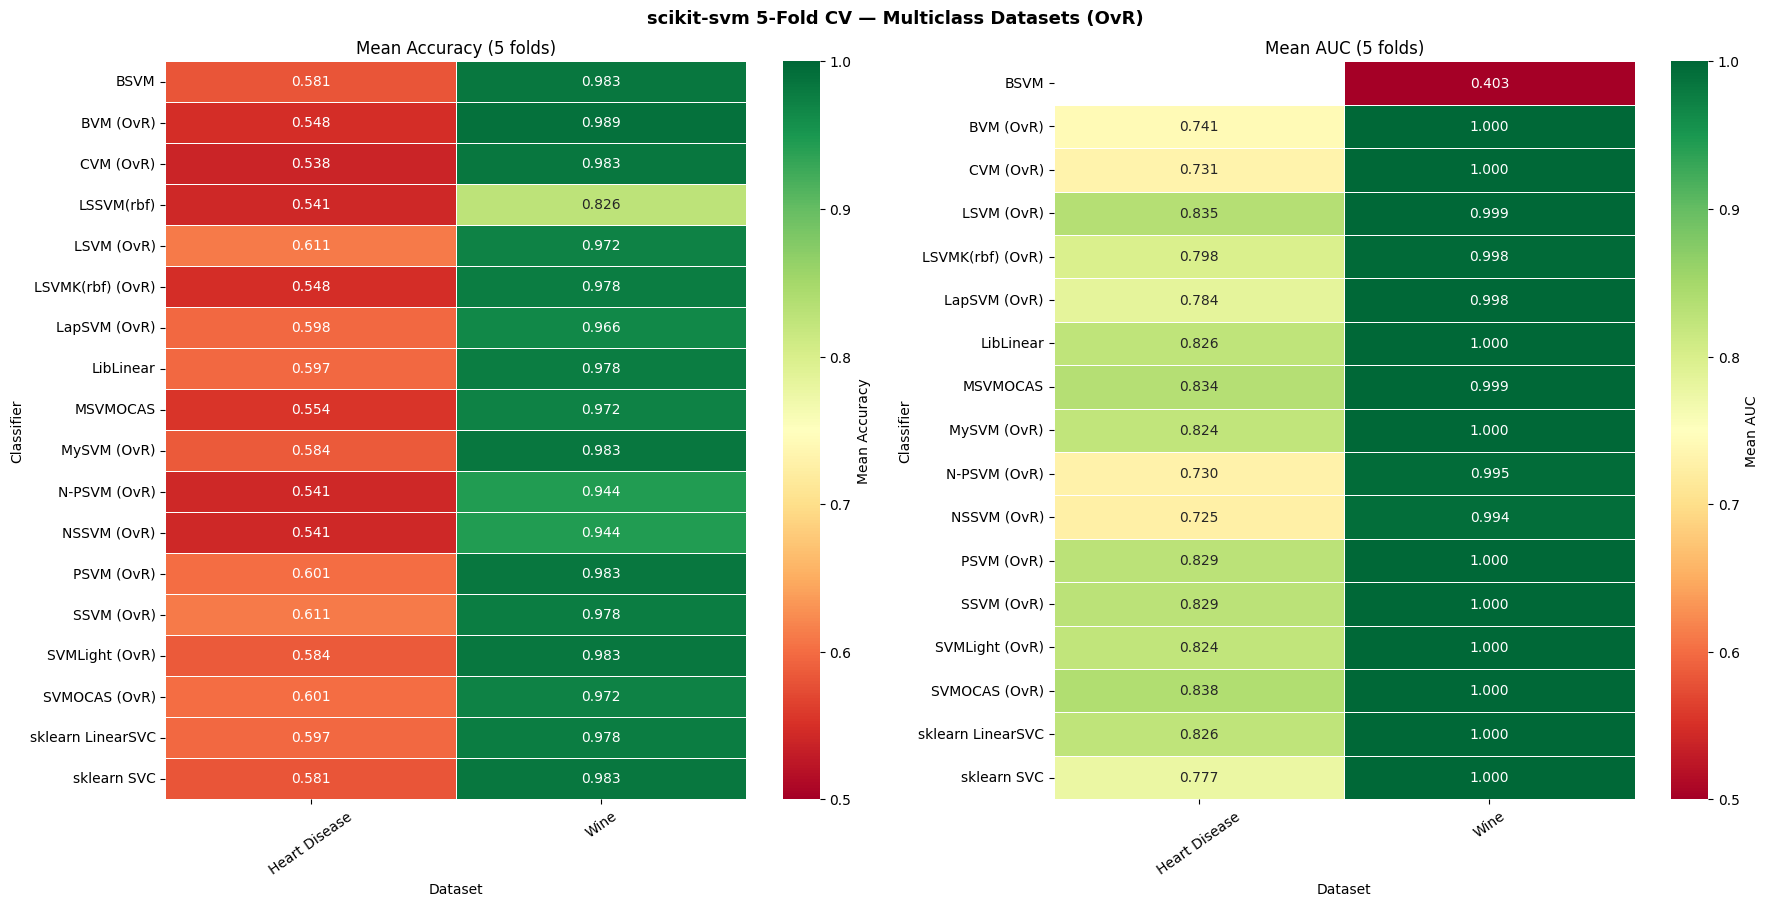

In [11]:
if __name__ == "__main__":
    print("=" * 64)
    print("  LOADING BINARY DATASETS")
    print("=" * 64)
    binary_datasets = load_datasets(_BINARY_SPECS)
    print()

    print("=" * 64)
    print("  LOADING MULTICLASS DATASETS")
    print("=" * 64)
    multi_datasets = load_datasets(_MULTICLASS_SPECS)
    print()

    binary_clfs = get_binary_classifiers()
    multi_clfs  = get_multiclass_classifiers()

    df_binary = run_benchmark(binary_datasets, binary_clfs, multiclass=False)
    df_multi  = run_benchmark(multi_datasets,  multi_clfs,  multiclass=True)

    display_summary(df_binary, "binary benchmark")
    display_summary(df_multi,  "multiclass benchmark")

    df_all = pd.concat([df_binary, df_multi], ignore_index=True)
    csv_path = os.path.join(RESULTS_DIR, "results_cv.csv")
    df_all.to_csv(csv_path, index=False)
    print(f"\nResults saved → {csv_path}")

    plot_results(df_binary, f"scikit-svm {N_FOLDS}-Fold CV — Binary Datasets",
                 save_path=os.path.join(RESULTS_DIR, "results_cv_binary.png"))
    plot_results(df_multi,  f"scikit-svm {N_FOLDS}-Fold CV — Multiclass Datasets (OvR)",
                 save_path=os.path.join(RESULTS_DIR, "results_cv_multiclass.png"))